**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Segundo Examen Parcial**

*18 de noviembre, 2025*




---


Nombre y Apellido: Alan Gabriel Baez

---



Número de registro: 919129

---



**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [ ]:
!pip install numpy_financial

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as npf
import seaborn as sns

## Unidad 4

### Ejercicio 1

Supongamos que una empresa opera en un mercado y tiene las siguientes funciones:

- Función de Ingreso Marginal ($IMg$): $$ IMg(q) = 150 - 0.05 \cdot q $$

  donde $q$ es la cantidad producida.

- Función de Costo Marginal ($CMg$): $$ CMg(q) = 0.003 \cdot q^2 - 0.4 \cdot q + 80 $$

Además, se sabe que el costo fijo de la empresa es de $\$2000$.

**Integración I**

- Recuperar la función de Ingreso Total, $I(q)$, asumiendo que el ingreso total es cero cuando la cantidad producida es cero: $I(0) = 0$.

In [ ]:
q = sp.symbols('q')

In [ ]:
img = 150-0.05*q # Defino la expresion del ingreso marginal
i = sp.integrate(img, q) # Realizo la integral para obtener el ingreso total
i # Como I(0)=0 no le agrego ningun ingreso fijo

-0.025*q**2 + 150.0*q

- Recuperar la función de Costo Total, $C(q)$.

In [ ]:
cf = 2000 # Defino el costo fijo
cmg = 0.003*q**2 - 0.4*q + 80 # Expresion del costo marginal
c = sp.integrate(cmg, q) + cf # Integro para obtener el costo total y le adiciono el costo fijo
c

0.001*q**3 - 0.2*q**2 + 80.0*q + 2000

- Calcular la función de Beneficio Total ($B(q)$)

In [ ]:
b = i - c
b

-0.001*q**3 + 0.175*q**2 + 70.0*q - 2000

- Encontrar la cantidad óptima ($q^{*}$). Esto es, determinar la cantidad de producción que maximiza el beneficio.

  Recordar: podemos lograr esto igualando el ingreso marginal al costo marginal, $IMg(q) = CMg(q)$, y resolviendo para $q$. Considerar solo valores de $q > 0$.

In [ ]:
q_opt = sp.solve(sp.Eq(img, cmg), q)[1]# Igualacion de costo marginal y ingreso marginal para calcular la cantidad optima
q_opt # me quedo solo con la solucion positiva

221.845140586238

- Calcular el Beneficio Máximo, $B^{*}(q)$.

In [ ]:
b_max = (b.subs(q, q_opt)) # substituyo la cantidad optima en la expresion del beneficio
b_max

11223.6637674586

- Visualizar las funciones de ingreso total, costo total y beneficio total en un mismo gráfico. Visualizar el punto de beneficio máximo. Interpretar el gráfico y sus componentes.

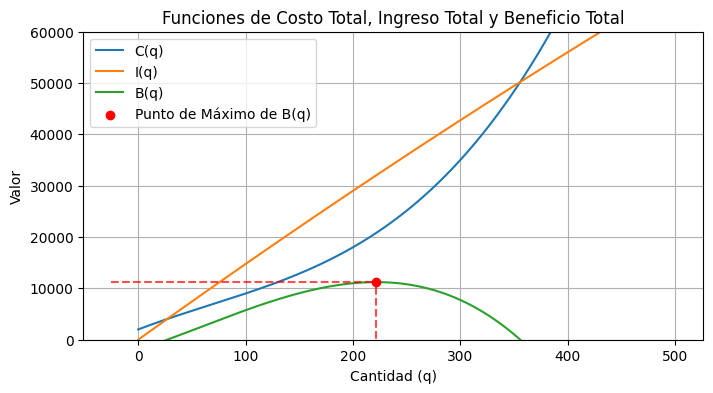

In [ ]:
q_grid = np.linspace(0, 500, 1000) # Ajusta el rango de q según sea necesario

# Convertir las expresiones simbólicas a funciones numéricas y evaluar en q_grid
c_num = sp.lambdify(q, c)(q_grid)
i_num = sp.lambdify(q, i)(q_grid)
b_num = sp.lambdify(q, b)(q_grid)

# Le indico el tamaño del grafico
fig, ax = plt.subplots(figsize=(8, 4))
# Grafico las funciones
ax.plot(q_grid, c_num, label="C(q)")
ax.plot(q_grid, i_num, label="I(q)")
ax.plot(q_grid, b_num, label="B(q)", color="tab:green")

# Gradico el beneficio maximo
ax.scatter(float(q_opt), float(b_max), color="red", zorder=5, label="Punto de Máximo de B(q)")
ax.vlines(x=float(q_opt), ymin=ax.get_ylim()[0], ymax=float(b_max), color='red', linestyle='--', alpha=0.7)
ax.hlines(y=float(b_max), xmin=ax.get_xlim()[0], xmax=float(q_opt), color='red', linestyle='--', alpha=0.7)

# Establezco el titulo, labels y demas
ax.set_title("Funciones de Costo Total, Ingreso Total y Beneficio Total")
ax.set_xlabel("Cantidad (q)")
ax.set_ylabel("Valor")
ax.legend()
ax.grid(True)
plt.ylim(0, 60000) # Indico limites para el eje y
plt.show()

Mientras IMg > CMg (beneficios crecientes): Producir la unidad adicional suma más al ingreso de lo que suma al costo. El incentivo de la empresa es producir más, ya que cada unidad extra incrementa el beneficio total. Esto aplica para cantidades menores a la cantidad óptima de producción(222)

Punto de Maximización (IMg = CMg): Este es el punto exacto donde la empresa estaria generando el mayor beneficio posible.

Cuando IMg < CMg (beneficios decrecientes): Producir una unidad adicional suma más al costo de lo que suma al ingreso. Esto aplica para cantidades mayores a la cantidad óptima de producción(222). El incentivo de la empresa es reducir la producción.

La zona de beneficios (donde B(q)>0) define el rango operacional donde la empresa puede subsistir. Los puntos donde el ingreso interseca al costo (donde B(q)=0) indican el umbral mínimo que la empresa debe superar para sobrevivir en el mercado.

### Ejercicio 2

Las funciones de oferta y demanda de cierto producto están dadas por:

$$O: p=45+2q$$

$$D:p= 144-q^2$$

**Integración II**

- Determinar el Excedente del Consumidor (EC) y el Excedente del Productor (EP).

In [ ]:
# Defino las funciones de oferta y demanda
Ps = 45 + 2*q
Pd = 144 - q**2
# Calculo el punto de equilibrio
q_opt = sp.solve(sp.Eq(Ps, Pd), q)[1]
q_opt # Me quedo con la solucion positiva

9

In [ ]:
# Hallo el precio de equilibrio
p_opt = (Pd.subs(q, q_opt))
p_opt

63

In [ ]:
# Procedo a calcular el EC con la integral definida
EC = sp.integrate(Pd - p_opt, (q, 0, q_opt))
EC

486

In [ ]:
# De igual forma para el EP
EP = sp.integrate(p_opt - Ps, (q, 0, q_opt))
EP

81

- Graficar ambas funciones en un mismo gráfico, donde el eje vertical (ordenadas) debe ser el precio y el horizontal (abscisas) la cantidad.

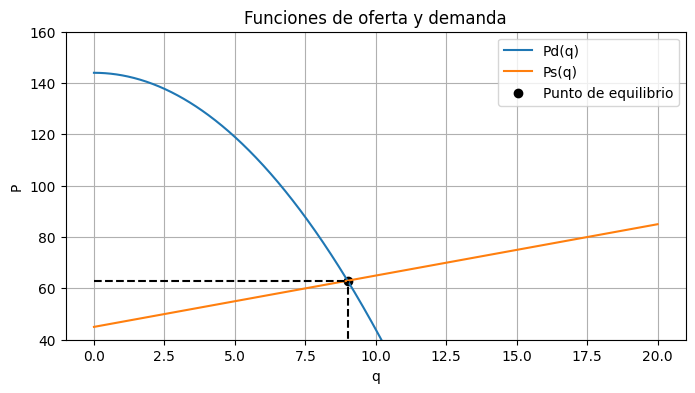

In [ ]:
# Grafico

q_grid = np.linspace(0, 20, 1000)
Pd_num = sp.lambdify(q, Pd)(q_grid)
Ps_num = sp.lambdify(q, Ps)(q_grid)

plt.figure(figsize=(8, 4))
plt.plot(q_grid, Pd_num, label='Pd(q)')
plt.plot(q_grid, Ps_num, label='Ps(q)')

plt.vlines(x=q_opt, ymin=0, ymax=p_opt, linestyles="--", color="black")
plt.hlines(y=p_opt, xmin=0, xmax=q_opt, linestyles="--", color="black")
plt.scatter([q_opt], [p_opt], c="black", label='Punto de equilibrio')

plt.title('Funciones de oferta y demanda')
plt.xlabel('q')
plt.ylabel('P')
plt.ylim(40,160)
plt.grid()
plt.legend()
plt.show()

- Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor. Interpretar.

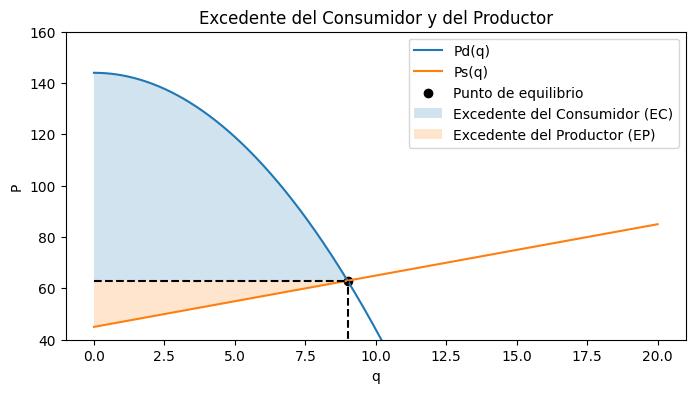

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(q_grid, Pd_num, label='Pd(q)')
plt.plot(q_grid, Ps_num, label='Ps(q)')

plt.vlines(x=q_opt, ymin=0, ymax=p_opt, linestyles="--", color="black")
plt.hlines(y=p_opt, xmin=0, xmax=q_opt, linestyles="--", color="black")
plt.scatter([q_opt], [p_opt], c="black", label='Punto de equilibrio')

plt.fill_between(
    q_grid,
    Pd_num,
    float(p_opt),
    where=(q_grid <= float(q_opt)),
    alpha=0.2,
    label='Excedente del Consumidor (EC)'
)

plt.fill_between(
    q_grid,
    float(p_opt),
    Ps_num,
    where=(q_grid <= float(q_opt)),
    alpha=0.2,
    label='Excedente del Productor (EP)'
)

plt.ylim(40,160)
plt.title('Excedente del Consumidor y del Productor')
plt.xlabel('q')
plt.ylabel('P')
plt.legend()
plt.show()

Interpretacion:

**Excedente del consumidor (EC)** es el ahorro o el beneficio neto que reciben los consumidores. Representa la diferencia entre lo que estaban dispuestos a pagar por el bien (el valor real que le asignaban, dado por la curva Pd​) y lo que realmente pagaron (el precio de equilibrio).

**Excedente del Productor (EP)** representa el beneficio que obtienen los productores por vender a un precio mayor al mínimo que aceptarían (su costo marginal).

Teniendo en cuenta las definiciones lo que nos indica el grafico es que el excedente del consumidor es mayor que el excedente del productor por lo que en la situacion que nos plantea el enunciado el consumidor estaria siendo el sujeto mas beneficiado en estas condiciones llevandose la porcion mas grande de bienestar.



### Ejercicio 3

Dada la función de Costo marginal

$$CMg=0.01-\dfrac{500}{x^{2}}$$

**Integración III**

- Hallar la función de Costo total cuando el costo fijo es F=50

In [ ]:
x = sp.symbols('x')
# Costo fijo = 50
cf = 50
# Costo marginal
cmg = 0.01-(500/x**2)
cmg

0.01 - 500/x**2

In [ ]:
c = sp.integrate(cmg, x) + cf # Integro para obtener el costo total y le adiciono el costo fijo
c

0.01*x + 50 + 500.0/x

- Calcular el costo total de producir 100 unidades

In [ ]:
# Costo total de 100 unidades
c_cien = (c.subs(x, 100))
c_cien

56.0000000000000

- Calcular, a través de una integral definida, el costo total variable acumulado entre 30 y 45 unidades.

In [ ]:
# Costo acumulado entre 30 y 45 unidades
c_acum = sp.integrate(cmg, (x, 30, 45))
c_acum

-5.40555555555556

- Graficar costo total y costo marginal. Interpretar el gráfico.

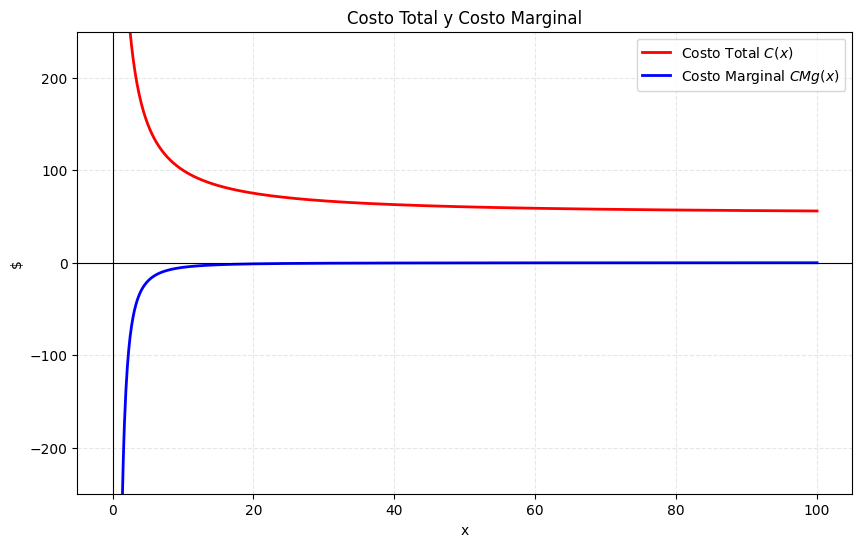

In [ ]:
x_grid = np.linspace(0.00001, 100, 1000)

c_f = sp.lambdify(x, c)(x_grid)
cmg_f = sp.lambdify(x, cmg)(x_grid)



plt.figure(figsize=(10, 6))

plt.plot(x_grid, c_f, label='Costo Total $C(x)$', linewidth=2, color='red')
plt.plot(x_grid, cmg_f, label='Costo Marginal $CMg(x)$', linewidth=2, color='blue')

plt.title('Costo Total y Costo Marginal')
plt.xlabel('x')
plt.ylabel('$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.ylim(-250,250)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()


Interpretacion: Se observa que al principio por mas que el costo marginal aumenta el costo total decrece por lo que se podria interpretar que el costo de producir una unidad adicional tiene poco impacto en el costo total. Luego entramos en una segunda fase del grafico donde las dos funciones se convierten en lineas horizontales por lo que el costo total pasaria a ser el mismo siempre para la produccion de grandes cantidades, este comportamiento se condice con la curva de costo marginal ya que la misma comienza a aportar tambien un costo constante por cada unidad adicional producida (siempre hablando de grandes cantidades).

## Unidad 5

### Ejercicio 4

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 11%, realice un análisis que contenga:

- Métricas financieras: VAN, TIR, TIRM y Payback Descontado (*Período de Recuperación Descontado, PRD*) e interprete cada una de ellas.

In [ ]:
inversion_inicial = -50000
cash_flows = [
    10000, -12000, 15000, 18000, 20000, 22000, 25000, 28000, -30000, 32000,
    -5000, 10000, 13000, 16000, -19000, 21000, -24000, 27000, -23000, 33000,
    -8000, 11000, -14000, 17000, 20000, 23000, 26000, -25000, 32000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows

In [ ]:
# 2) Fórmula de Equivalencia
def equivalencia(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

# Tasa de descuento anual
tasa_descuento_anual_1 = 0.11

# Definir la tasa de descuento mensual
tasa_descuento_van_1 = equivalencia(tasa_descuento_anual_1, 30, 365)
tasa_descuento_van_1

0.008614427970481175

In [ ]:
# VAN
# Flujos para el van
flujos_van = nuevo_cash_flow

# Uso numpy-financial para el van
van_1 = npf.npv(tasa_descuento_van_1, flujos_van)
print(f"El VAN es: {van_1:.2f}")

El VAN es: 179241.37


Interpretacion: El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa, ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial. Segun el VAN el proyecto es rentable

In [ ]:
# TIR
# Flujos para el TIR
flujos_tir = nuevo_cash_flow
# TIR con numpy-financial
tir = npf.irr(flujos_tir)
print(f"La Tasa Interna de Retorno (TIR) es: {tir:.2%}")

La Tasa Interna de Retorno (TIR) es: 19.65%


Interpretacion: La TIR es mucho mayor que la tasa de descuento (19,65% > 0,86%). Esto significa que la rentabilidad intrínseca del proyecto está por encima del rendimiento mínimo exigido. Segun el TIR el proyecto es rentable

In [ ]:
# TIRM
# Flujos para el TIRM
flujos_tirm_1 = nuevo_cash_flow
tirm_1 = npf.mirr(flujos_tirm_1, tir, tasa_descuento_van_1) # (FLUJO, TASA DE FINANCIAMIENTO,  TASA DE REINVERSION)

print("La Tasa interna de Retorno Modificada es :", tirm_1*100,"%")

La Tasa interna de Retorno Modificada es : 6.867207754707683 %


Interpretacion: La TIRM es mayor que la tasa de descuento (6,86%>0,86%). Esto indica que la rentabilidad efectiva del proyecto, asumiendo que tanto los flujos de caja positivos se reinvierten a una tasa de reinversion como que los flujos de caja negativos se financian a una tasa de financiamiento, supera al costo de capital. Segun el TIRM el proyecto es rentable.

In [ ]:
# Definir la tasa de descuento
r_desc_prd = tasa_descuento_van_1

# Obtener los flujos
flujos_prd = nuevo_cash_flow

# Obtener la inversión inicial (valor absoluto del primer flujo de caja)
I_inicial = abs(flujos_prd[0])


cumulative_discounted_cash_flow = 0
prd = None


for t in range(1, len(flujos_prd)):
    # Descontar el flujo de caja actual
    discounted_flow = flujos_prd[t] / (1 + r_desc_prd)**t
    cumulative_discounted_cash_flow += discounted_flow

    # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
    if cumulative_discounted_cash_flow >= I_inicial:
        # Si es así, calcular el período de recuperación descontado
        remaining_investment = I_inicial - (cumulative_discounted_cash_flow - discounted_flow)
        prd = t - 1 + (remaining_investment / discounted_flow)
        break

if prd is not None:
    print(f"El Periodo de Recuperación Descontado (PRD) es: {prd:.2f} meses")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")

El Periodo de Recuperación Descontado (PRD) es: 5.03 meses


Interpretacion: Indica que la suma acumulada de los flujos de caja descontados logra igualar a la inversión inicial en el periodo analizado. Por lo que en 5,03 meses recupero lo invertido inicialmente en el proyecto

- Grafique el flujo de fondos.

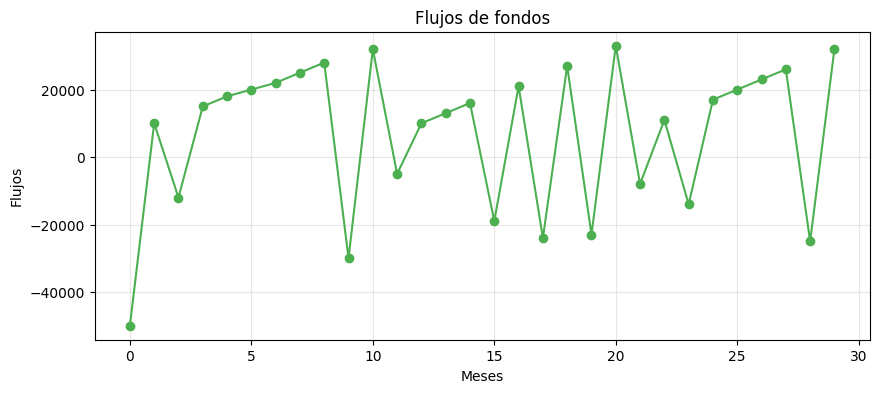

In [ ]:
# Grafico del flujo de fondos
plt.figure(figsize=(10, 4))

plt.plot(np.arange(0,len(nuevo_cash_flow),1),nuevo_cash_flow, marker='o', color='#4CAF50')
plt.title('Flujos de fondos')
plt.xlabel('Meses')
plt.ylabel('Flujos')
plt.grid(True, alpha=0.3)
plt.show()

- Grafique el VAN a diferentes tasas de descuento de costo de capital. Marque en dicho gráfico la TIR. Explique el gráfico y sus componentes.

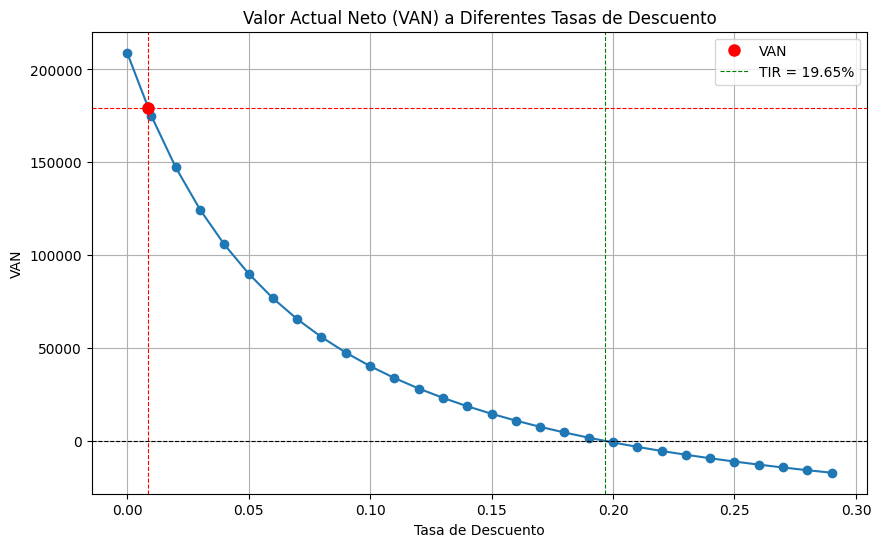

In [ ]:
# Crear un rango de tasas de descuento para evaluar el VAN
tasas_descuento_rango = np.arange(0, 0.3, 0.01)

# Calcular el VAN para cada tasa de descuento en el rango
van_por_tasa = [npf.npv(tasa, flujos_van) for tasa in tasas_descuento_rango]

# Visualizar el VAN a distintas tasas de descuento
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento_rango, van_por_tasa, marker='o', linestyle='-')

# grafico el punto del VAN del proyecto
plt.plot(tasa_descuento_van_1, van_1, 'ro', markersize=8, label='VAN')

# Genero lineas para hacer enfasis en el punto del VAN del proyecto
plt.axvline(tasa_descuento_van_1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(van_1, color='red', linestyle='--', linewidth=0.8)

plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Línea en VAN = 0 para identificar la TIR
plt.axvline(tir, color='green', linestyle='--', linewidth=0.8, label=f'TIR = {tir:.2%}') # Mostrar la TIR
plt.legend()
plt.show()

El gráfico muestra que la curva del VAN cruza el eje horizontal (VAN=0) en el punto TIR = 19,65%. Al evaluar el proyecto con la tasa de descuento del 0,86% el punto correspondiente en la curva del VAN que nos dio el proyecto (punto rojo) se encuentra por encima de la línea horizontal de VAN=0, por lo que tenemos una confirmacion visual de que conviene aceptar el proyecto

- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 17% anual. Realice el análisis nuevamente e interprete los resultados.

In [ ]:
# Tasa de descuento anual
tasa_descuento_anual_2 = 0.17

# Definir la tasa de descuento mensual
tasa_descuento_van_2 = equivalencia(tasa_descuento_anual_2, 30, 365)
tasa_descuento_van_2

0.01298803901622203

In [ ]:
# VAN
# Flujos para el van
flujos_van_2 = nuevo_cash_flow

# Uso numpy-financial para el van
van_2 = npf.npv(tasa_descuento_van_2, flujos_van_2)
print(f"El VAN es: {van_2:.2f}")

El VAN es: 166069.47


Interpretacion: Veo que el VAN a bajado con esta nueva tasa de descuento por lo que es menos rentable que antes, crea menos valor para la empresa.

Interpretacion de la TIR: La TIR sigue siendo la misma, por lo que la velocidad de crecimiento de la inversion es igual

In [ ]:
# TIRM
# Flujos para el TIRM
flujos_tirm_2 = nuevo_cash_flow
tirm_2 = npf.mirr(flujos_tirm_2, tir, tasa_descuento_van_2) # (FLUJO, TASA DE FINANCIAMIENTO,  TASA DE REINVERSION)

print("La Tasa interna de Retorno Modificada es :", tirm_2*100,"%")

La Tasa interna de Retorno Modificada es : 7.0972575613339695 %


Interpretacion: EL TIRM tambien se redujo por lo que la rentabilidad ajustada es inferior y por lo tanto menos rentable que con la otra tasa de descuento.

In [ ]:
# Definir la tasa de descuento
r_desc_prd = tasa_descuento_van_2

# Obtener los flujos
flujos_prd = nuevo_cash_flow

# Obtener la inversión inicial (valor absoluto del primer flujo de caja)
I_inicial = abs(flujos_prd[0])


cumulative_discounted_cash_flow = 0
prd = None


for t in range(1, len(flujos_prd)):
    # Descontar el flujo de caja actual
    discounted_flow = flujos_prd[t] / (1 + r_desc_prd)**t
    cumulative_discounted_cash_flow += discounted_flow

    # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
    if cumulative_discounted_cash_flow >= I_inicial:
        # Si es así, calcular el período de recuperación descontado
        remaining_investment = I_inicial - (cumulative_discounted_cash_flow - discounted_flow)
        prd = t - 1 + (remaining_investment / discounted_flow)
        break

if prd is not None:
    print(f"El Periodo de Recuperación Descontado (PRD) es: {prd:.2f} meses")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")

El Periodo de Recuperación Descontado (PRD) es: 5.08 meses


Interpretacion: El PRD es mayor por lo que la suma acumulada de los flujos de caja descontados tardan mas en igualar a la inversión inicial en el periodo analizado. Por lo tanto nuevamente es menos rentable con esta tasa de descuento del 17% anual

- Haga un gráfico comparativo de ambas situaciones.

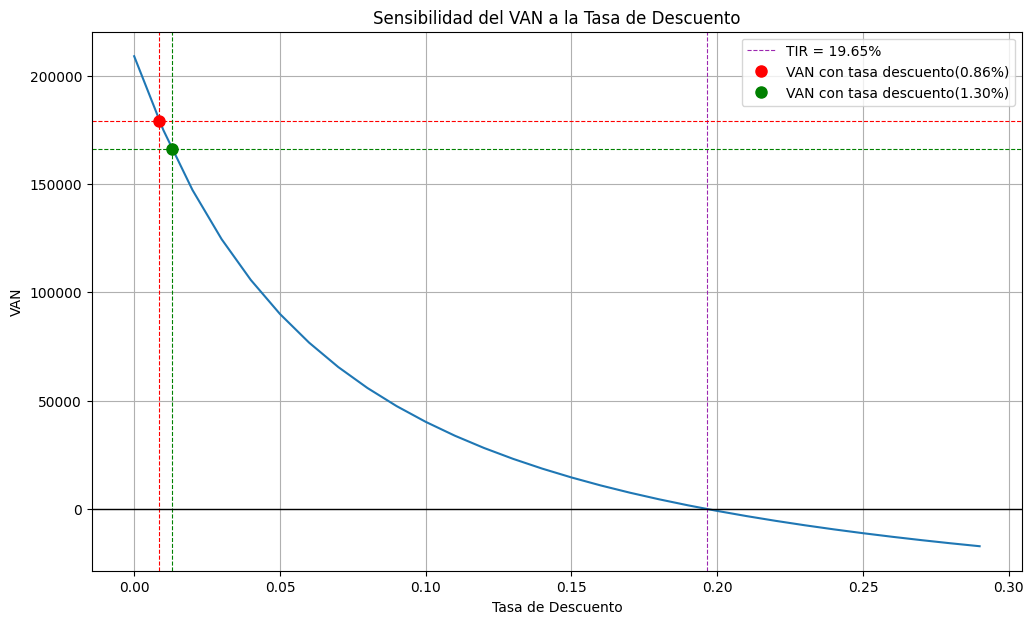

In [ ]:
# Definimos rango de tasas de descuento
tasas_descuento_rango = np.arange(0, 0.3, 0.01)

# Calculamos VAN para cada tasa
van_proyecto_rango = [npf.npv(tasa, nuevo_cash_flow) for tasa in tasas_descuento_rango]

# Creo el grafico
plt.figure(figsize=(12, 7))
plt.plot(tasas_descuento_rango, van_proyecto_rango, linestyle='-')
plt.axvline(tir, color='#9C27B0', linestyle='--', linewidth=0.8, label=f'TIR = {tir:.2%}') # Mostrar la TIR

plt.plot(tasa_descuento_van_1, van_1, 'ro', markersize=8, label=f'VAN con tasa descuento({tasa_descuento_van_1*100:.2f}%)')
plt.plot(tasa_descuento_van_2, van_2, 'go', markersize=8, label=f'VAN con tasa descuento({tasa_descuento_van_2*100:.2f}%)')

plt.axvline(tasa_descuento_van_1, color='red', linestyle='--', linewidth=0.8)
plt.axhline(van_1, color='red', linestyle='--', linewidth=0.8)

plt.axvline(tasa_descuento_van_2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(van_2, color='green', linestyle='--', linewidth=0.8)

plt.title('Sensibilidad del VAN a la Tasa de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.show()

Interpretacion de los dos escenarios:

Proyecto A: es el proyecto con la tasa de descuento anual de 11%

Proyecto B: es el proyecto con la tasa de descuento anual de 17%

- Según el VAN, el Proyecto A es preferible ya que tiene un VAN menos negativo (o más positivo).
- La TIR es igual en ambos casos por lo que no se distingue uno del otro segun este criterio.
- Según la TIRM, el Proyecto A es preferible ya que ofrece una mayor tasa de retorno modificada.
- Según el Periodo de Recuperación Descontado (PRD) el proyecto A recupera antes la inversion inicial antes que el proyecto B.

**Conclusion final**

¿Es rentable o no? AMBOS proyectos son rentables, ya que cumplen con los criterios de VAN>0, TIR>r, TIRM>r.

¿Conviene o no conviene? Con cualquiera de las dos tasas de descuento indicadas en el ejercicio conviene hacer el proyecto.

El proyecto A es el preferido debido a que tiene mejores indicadores que el proyecto B.


### Ejercicio 5

Importe el dataset `Cripto_metrics.csv` y realice:
- exploración inicial del mismo.

In [ ]:
df=pd.read_csv('/content/crypto_metrics.csv')
df

,coin,volatility,liquidity,max_drawdown,market_cap,age
0,Bitcoin,0.064226,33182009070,0.236646,2241685418265,6056
1,Ethereum,0.131053,27684741311,0.551584,410830923425,3657
2,XRP,0.129846,6646034445,0.469216,165228747378,365
3,Tether,0.001084,68142343377,0.001241,163854374085,365
4,BNB,0.079374,1235127485,0.316967,102853681381,2948
5,Solana,0.135935,4626383045,0.373265,85496319358,365
6,USDC,0.000835,10055291522,0.000517,64182252899,365
7,TRON,0.074014,1381341229,0.295966,30467500076,2897
8,Lido Staked Ether,0.132987,61983228,0.551375,30463822909,365
9,Dogecoin,0.172444,2219770457,0.483479,28853925870,4256


In [ ]:
df.isna().sum() # Verifico si hay valores nulos

,0
coin,0
volatility,0
liquidity,0
max_drawdown,0
market_cap,0
age,0


No hay valores nulos

In [ ]:
df.describe() # Breve descripcion de la base

,volatility,liquidity,max_drawdown,market_cap,age
count,20.000000,2.000000e+01,20.000000,2.000000e+01,20.00000
mean,0.120870,7.978204e+09,0.406771,1.726995e+11,1390.10000
std,0.056371,1.688413e+10,0.178239,4.962043e+11,1728.18901
min,0.000835,7.890620e+06,0.000517,9.777484e+09,365.00000
25%,0.078034,2.707386e+08,0.311717,1.166249e+10,365.00000
50%,0.132319,1.188968e+09,0.453238,2.706177e+10,365.00000
75%,0.156315,5.131296e+09,0.552251,8.983566e+10,2882.75000
max,0.210919,6.814234e+10,0.605611,2.241685e+12,6056.00000


In [ ]:
# Información de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   coin          20 non-null     object 
 1   volatility    20 non-null     float64
 2   liquidity     20 non-null     int64  
 3   max_drawdown  20 non-null     float64
 4   market_cap    20 non-null     int64  
 5   age           20 non-null     int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.1+ KB


- Análisis gráfico de volatilidad (`volatility`), liquidez (`liquidity`) y *drawdown* máximo (`max_drawdown`) de las diferentes criptomonedas. Saque conclusiones.

  **Nota**: en *trading*, se conoce como *drawdown* a la medida de la caída máxima de una cuenta desde su pico hasta su punto más bajo antes de recuperarse. Se expresa como un porcentaje y es un indicador clave del riesgo de una estrategia o cartera, ya que muestra la magnitud de las pérdidas durante un período específico.

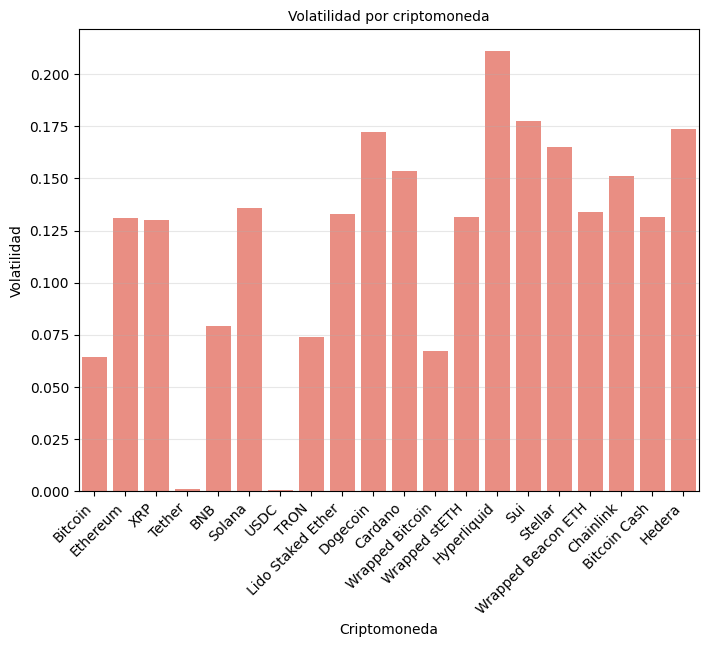

In [ ]:
# Grafico de Volatilidad
plt.figure(figsize=(8, 6))
sns.barplot(x='coin', y='volatility', data=df, color='salmon')

plt.title('Volatilidad por criptomoneda', fontsize=10)
plt.xlabel('Criptomoneda')
plt.ylabel('Volatilidad')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

Hyperliquid es la que tiene mayor volatilidad y por lo tanto la mas riesgosa a la hora de invertir en esa criptomoneda. Si quisiera hacer inversiones conservadoras me inclinaria a invertir en monedas como USDC o Tether

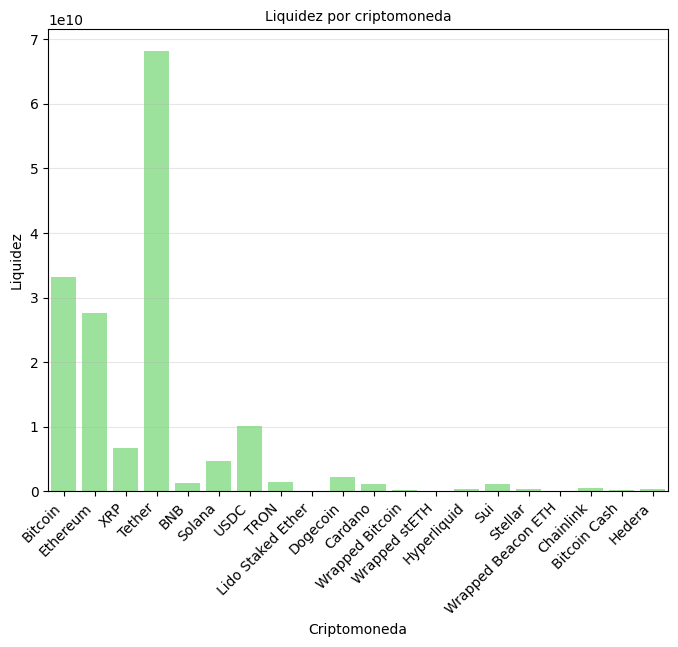

In [ ]:
# Grafico de Liquidez
plt.figure(figsize=(8, 6))
sns.barplot(x='coin', y='liquidity', data=df, color='lightgreen')

plt.title('Liquidez por criptomoneda', fontsize=10)
plt.xlabel('Criptomoneda')
plt.ylabel('Liquidez')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

Si quisiera hacer operaciones a corto plazo la liquidez es un factor importante debido a tener en cuenta, por lo que si quiesiera realizar dichas operaciones eligiria las monedas con mayor liquidez como Tether, Bitcoin, Etherium

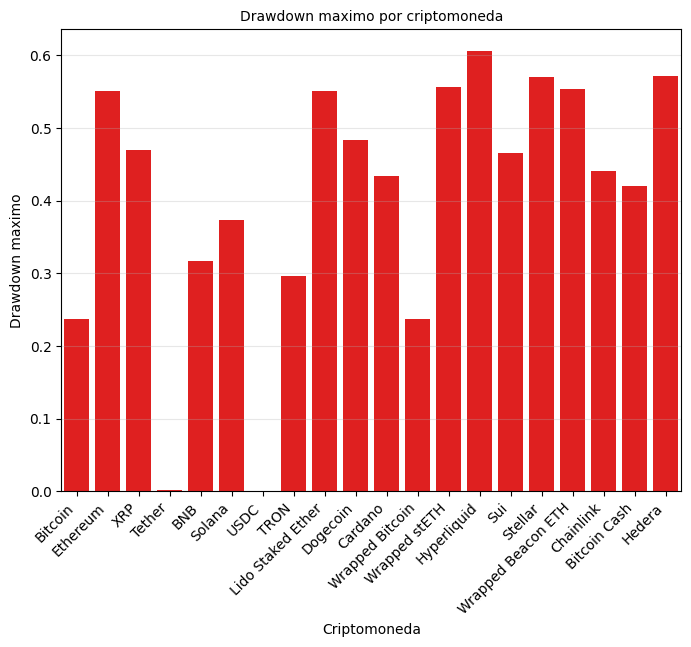

In [ ]:
# Grafico de Drawdown
plt.figure(figsize=(8, 6))
sns.barplot(x='coin', y='max_drawdown', data=df, color='red')

plt.title('Drawdown maximo por criptomoneda', fontsize=10)
plt.xlabel('Criptomoneda')
plt.ylabel('Drawdown maximo')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

- Compare `Tether` y `USDC` versus `Solana` y `Cardano`. Saque conclusiones.